# Change Analysis

In [ ]:
from iomeval.llm_eval.changes import *

from fastcore.all import *
from iomeval.readers import load_evals
from pathlib import Path

In [ ]:
p = Path().home() / 'iomeval/data/requester_by_report_id.json'
lut = p.read_json()
evls_test = L(lut.keys())

ROOT_PATH = Path.home() / 'iomeval'
DATA_PATH = ROOT_PATH / 'data'
RESULTS_PATH = DATA_PATH/ 'results'
EVALS_PATH = ROOT_PATH / 'nbs/files/test/evaluations.json'

# Contains latest backed up data before new deployment
LATEST_TAG_PATH = Path.home() / 'tagapp/backups/20260311_115159/data'

evals = load_evals(EVALS_PATH)

In [ ]:
dfs = all_deltas(evls_test, RESULTS_PATH, LATEST_TAG_PATH)

## What we changed?

- new prompts integrating the following changes:
    - GCM 23 downgrading
        - "IMPORTANT NOTE ON GCM OBJECTIVE 23" of https://github.com/franckalbinet/iomeval/blob/main/nbs/files/prompts/gcms.md

    - SRF enablers reframed
        "CRITICAL DISTINCTION: ENABLER AS INSTITUTIONAL CAPACITY VS. PROGRAMMATIC TOOL" section of https://github.com/franckalbinet/iomeval/blob/main/nbs/files/prompts/srf_enablers.md

    - tagging relevance score ranges from `"Not Relevant", "Peripheral" ("Supplementary" in previous version), "Relevant", "Fundamental"`

    - terminology warning about the use of word "Findings":
    ```"Findings" has a specific formal meaning in IOM evaluation reports. When the term appears in report excerpts, you may reference it. However, do not use "finding(s)" in your own analytical language (e.g., do not write "we find that..." or "a key finding is..."): this could be confused with the report's formal findings```
    
    - make clear we work with excerpt (executive summary, intro, summary, background, evaluation scope, conclusions, recommendations, lessons learnt)
    ```You have only accessed excerpts of each report, not the full document. All claims about report content must reflect this limitation. Use hedged language throughout ("the excerpts suggest," "based on the sections reviewed," "the excerpts I accessed indicate") and never assert what the full report contains as a whole. This also means you may miss relevant content that exists outside the excerpts — acknowledge this where appropriate.``` The "Findings" section will receive a dedicated treatment in later iterations

    - GCM descriptions added
    - also more diligent selection of sections (after curation)

How did these changes affect tagging?

## Score changes overview

### GCM objectives

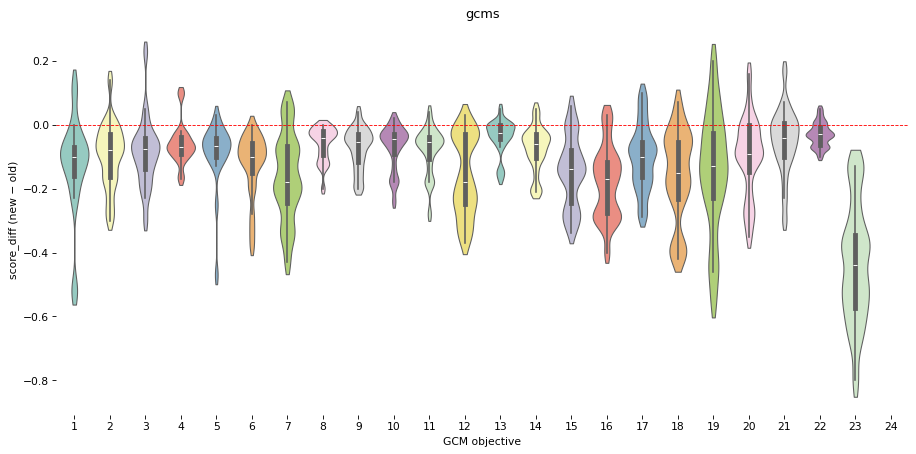

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective', figsize=(12, 6), dpi=77)

### SRF Enablers

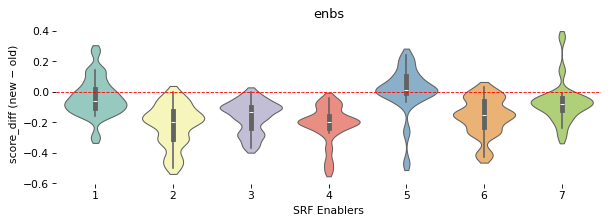

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers', figsize=(8, 3), dpi=77)

### SRF Cross-Cutting Priorities

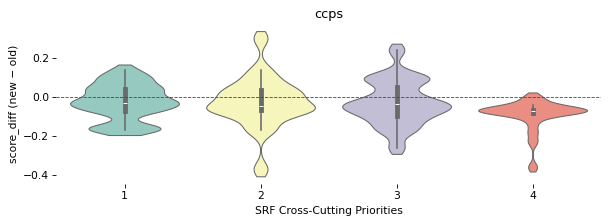

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities', figsize=(8, 3), dpi=77)

## Rank changes overview

Among all themes where previous relevance score was `> 0.83` (**FUNDAMENTAL**), what percentage of them have undergone a change in rank (`rank_diff != 0`)

In [ ]:
dfs[dfs.score_old > 0.83].groupby('mapping_type').apply(lambda x: 100 * (x.rank_diff != 0).sum() / len(x)).round(1).sort_values()

mapping_type
ccps    16.7
gcms    34.3
outs    40.7
enbs    44.4
dtype: float64

## Per evaluation report

In [ ]:
set(lut.values())

{'Andres', 'Davide', 'elma', 'pip', 'rogers'}

In [ ]:
rpts = [k for k,v in lut.items() if v=='rogers']
rpts

['56e6f2bc9f55a0c6d07341ddde1283db',
 '1d7e6d2d445145d1d350b48b72b36681',
 'dba9eb1220368d28682d8531108e767d',
 '8dd2261100ff5d714e73b411eed043d5']

In [ ]:
df = dfs[dfs.evl_id == rpts[0]]

Was "FUNDAMENTAL" (relevance score > 0.83) and was among the 3 top ranked and its rank has changed

In [ ]:
coi = ['mapping_type', 'theme_id', 'score_old', 'score_new', 'rank_old', 'rank_new', 'rank_diff']
print(df.query('rank_old <= 3 & rank_diff != 0 & score_new > 0.83')[coi])

Empty DataFrame
Columns: [mapping_type, theme_id, score_old, score_new, rank_old, rank_new, rank_diff]
Index: []


Has become "FUNDAMENTAL" (relevance score > 0.83) and is among the 3 top ranked while was not in previous version

In [ ]:
print(df.query('rank_new <= 3 & rank_old > 3 & score_new > 0.83')[coi])

Empty DataFrame
Columns: [mapping_type, theme_id, score_old, score_new, rank_old, rank_new, rank_diff]
Index: []


In [ ]:
for rpt in rpts:
    df = dfs[dfs.evl_id == rpt]
    print(f'{rpt}:\n')
    print(df.query('rank_old <= 3 & rank_diff != 0 & score_new > 0.65')[coi])
    print(df.query('rank_new <= 3 & rank_old > 3 & score_new > 0.65')[coi])

56e6f2bc9f55a0c6d07341ddde1283db:

    mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
593         gcms        1       0.88       0.72         3         2          1
    mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
613         gcms        7       0.78       0.70         5         3          2
623         outs     3d42       0.68       0.68         4         2          2
1d7e6d2d445145d1d350b48b72b36681:

    mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
663         outs     3d31       0.88       0.88         3         2          1
664         outs     3d32       0.92       0.85         2         3         -1
    mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
638         gcms       12       0.72       0.72         4         2          2
dba9eb1220368d28682d8531108e767d:

    mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
668         ccps        2 

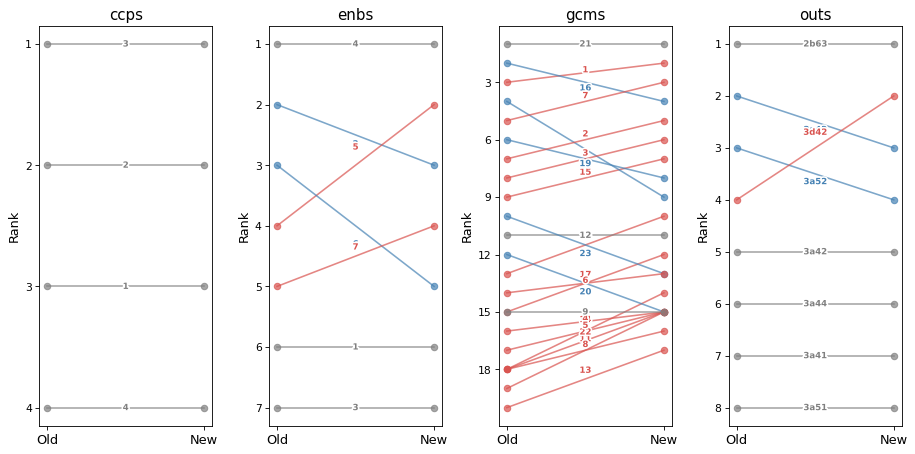

In [ ]:
plot_rank_changes(dfs[dfs.evl_id == rpts[0]], figsize=(12, 6), dpi=77)

Is it possible to print and plot a matplotlib graph in a for loop?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, absolutely. You just need to call `plt.show()` at the end of each iteration to flush the figure. For example:

```python
for rpt in rpts:
    df = dfs[dfs.evl_id == rpt]
    print(f'\n{rpt}')
    plot_rank_changes(df, figsize=(12, 6), dpi=77)
    plt.show()
```

<details class='token-usage-details'><summary>$0.0855</summary>

`total=15,728 | in=15,624 | out=104 | cached=0.0% | cache_new=11,414 | $0.0855`

</details>



56e6f2bc9f55a0c6d07341ddde1283db


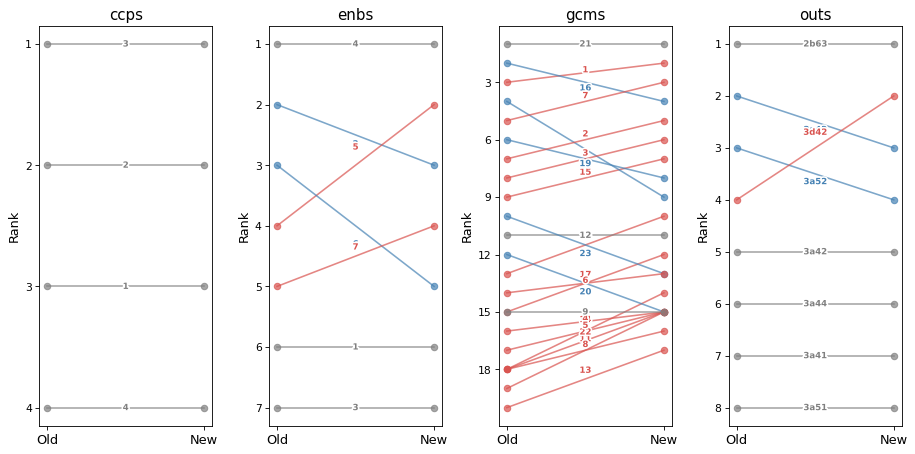


1d7e6d2d445145d1d350b48b72b36681


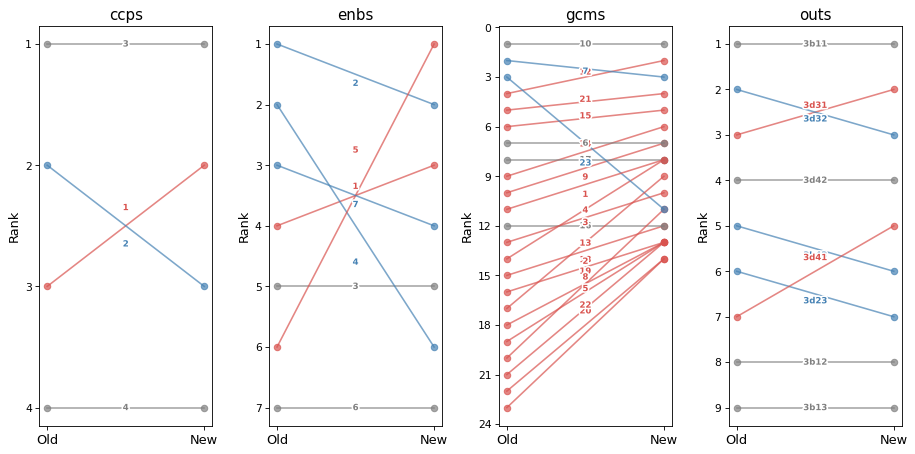


dba9eb1220368d28682d8531108e767d


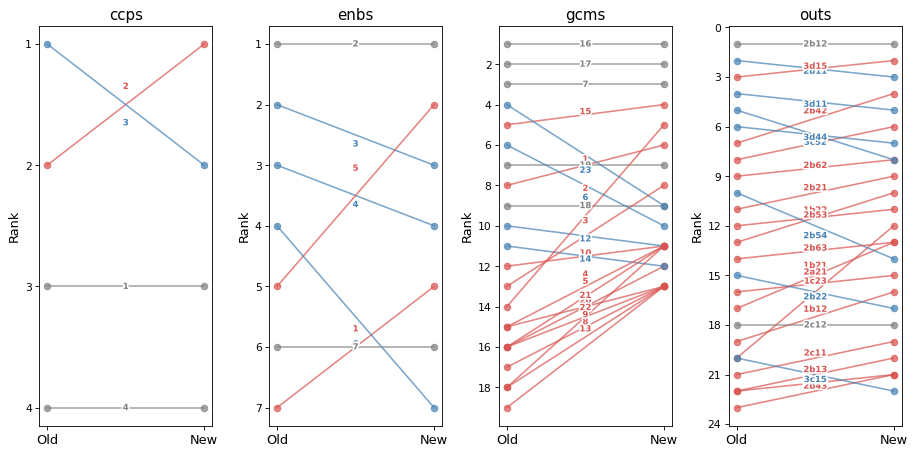


8dd2261100ff5d714e73b411eed043d5


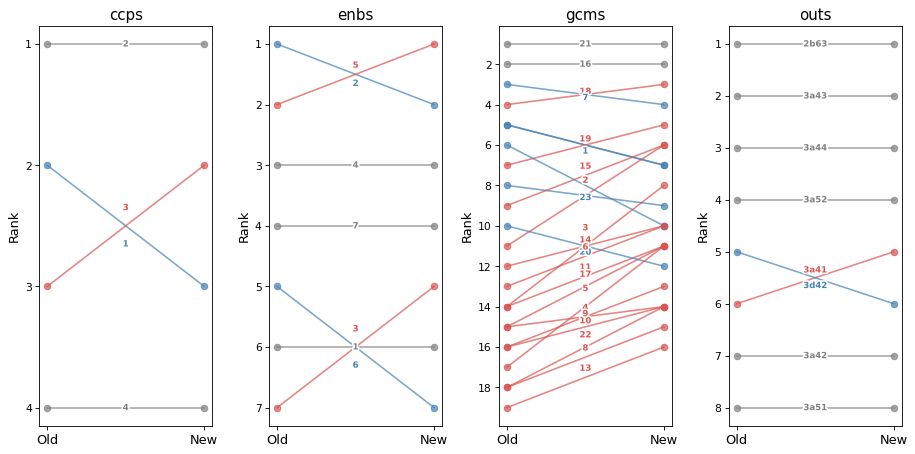

In [ ]:
import matplotlib.pyplot as plt
for rpt in rpts:
    df = dfs[dfs.evl_id == rpt]
    print(f'\n{rpt}')
    plot_rank_changes(df, figsize=(12, 6), dpi=77)
    plt.show()

No the print statement is printed at the end. Look at my plot function:
```
def plot_rank_changes(
    df:pd.DataFrame, # input DataFrame
    **kwargs # passed to plt.subplots (e.g. figsize, dpi)
    ):
    "Slope chart of rank changes (old → new) per mapping type, coloured by direction"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), sharey=False, **kwargs)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        for _, row in grp.iterrows():
            color = 'steelblue' if row.rank_diff < 0 else '#d9534f' if row.rank_diff > 0 else 'grey'
            ax.plot([0, 1], [row.rank_old, row.rank_new], marker='o', color=color, alpha=0.7)
            ax.text(0.5, (row.rank_old + row.rank_new) / 2 + (-0.15 * row.rank_diff), row.theme_id,
                    ha='center', va='center', fontsize=8, fontweight='bold', color=color,
                    path_effects=[withStroke(linewidth=3, foreground='white')])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Old', 'New'], fontsize=12)
        ax.invert_yaxis()
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_title(mt, fontsize=14, fontweight='normal')
        ax.set_ylabel('Rank', fontsize=12)
    plt.tight_layout()
    plt.show()
```

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Your `plot_rank_changes` already calls `plt.show()` internally, so calling it again in the loop is redundant — but the real issue is the `print` appearing after the plot. This is because solveit displays outputs (including plots) after all cell output is collected. Move the print inside the function, or just add a `fig.suptitle` instead:

```python
for rpt in rpts:
    df = dfs[dfs.evl_id == rpt]
    plot_rank_changes(df, figsize=(12, 6), dpi=77)
```

And in `plot_rank_changes`, add the report id as a super title just before `plt.tight_layout()`:

```python
fig.suptitle(rpt, fontsize=10)
```

That way the label is part of the figure itself and will always appear with the plot.

<details class='token-usage-details'><summary>$0.0440</summary>

`total=18,174 | in=17,968 | out=206 | cached=63.5% | cache_new=4,193 | $0.0440`

</details>


In [ ]:
from dialoghelper.stdtools import *

In [ ]:
add_msg?

```python
async def add_msg(
    content:str, # Content of the message (i.e the message prompt, code, or note text)
    msg_type:str='note', # Message type, can be 'code', 'note', or 'prompt'
    run:bool=False, # Run the message?
    placement:str='', # Location to place message. Can be 'at_start' or 'at_end', and if id provided or in curr dlg can also be 'add_after' or 'add_before'. Defaults to 'at_end' if no id and not targeting curr dlg
    id:str=None, # id of message that placement is relative to (if None, uses current message)
    dname:str='', # Dialog to add to; defaults to current dialog (`run` only has a effect if dialog is currently running)
    wait:bool=False, # Wait for and return response? (if `run`)
    poll:float=0.5, # Frequency of polling to check for completion (if `wait`)
    output:str='', # Prompt/code output; Code outputs must be .ipynb-compatible JSON array
    time_run:str | None='', # When was message executed
    is_exported:int | None=0, # Export message to a module?
    skipped:int | None=0, # Hide message from prompt?
    i_collapsed:int | None=0, # Collapse input?
    o_collapsed:int | None=0, # Collapse output?
    heading_collapsed:int | None=0, # Collapse heading section?
    pinned:int | None=0, # Pin to context?
)->str: # Message ID of newly created message

```



```
Add/update a message to the queue to show after code execution completes, and optionally run it.
Code messages are run using pyrun's restricted sandbox.
**NB**: when creating multiple messages in a row, after the 1st message set `id` to the result of the last `add_msg` call,
otherwise messages will appear in the dialog in REVERSE order.
If `dname` is None, the current dialog is used. If it is an open dialog, it will be updated interactively with real-time updates to the browser. If it is a closed dialog, it will be updated on disk. Dialog names must be paths relative to solveit root (if starting with `/`, e.g. `/myproject/dlg`) or relative to the current dialog's folder (if not starting with `/`), and should *not* include the .ipynb extension. **Use absolute paths when targeting dialogs outside the current dialog's folder tree.**
```



**File:** `/usr/local/lib/python3.12/site-packages/dialoghelper/core.py`

**Type:** function

Don't you think I could instead for each report, create new cells programmatically? It could include:
- a markdown cell with the report title
- the overal rank change plot for the given report
- the for every theme identified based on particular query `df.query('rank_old <= 3 & rank_diff != 0 & score_new > 0.65')[coi]`
    - if non empty
    - a markdown cell with the theme id
    - a markdown cell with the theme description
    - output the result of the queried dataframe
    - show the model reasoning before and after
    - we could design a template markdown for that?


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, that's a great use of `add_msg`! It would produce a much more readable, navigable analysis than a loop of plots. Let me suggest we build it up incrementally.

A good first step would be designing the markdown template for a single theme. Something like:

```markdown
### GCM Objective 7 — _Addresses irregular migration_

| | Old | New |
|---|---|---|
| Score | 0.78 | 0.65 |
| Rank | 2 | 5 |

**Reasoning (old):** ...

**Reasoning (new):** ...
```

Before going further though, a couple of things to clarify:

1. Where does the theme description and reasoning text live — in `dfs`, or do you load them from the JSON result files?
2. Should the generated cells appear in the **current dialog**, or in a **new dedicated dialog** per report (or one per reviewer)?

<details class='token-usage-details'><summary>$0.0598</summary>

`total=19,424 | in=19,141 | out=283 | cached=53.5% | cache_new=7,803 | $0.0598`

</details>


In [ ]:
new_r = load_result(rpts[0], RESULTS_PATH)

In [ ]:
new_r['meta']['Title']
new_r['mappings'].keys()
new_r['mappings']['gcms'][0]

{'theme_id': '1',
 'theme_title': 'Collect and utilize accurate and disaggregated data as a basis for evidence-based policies',
 'relevance_score': 0.72,
 'reasoning': "Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 1. The project explicitly uses IOM's Displacement Tracking Matrix (DTM) as a core component — described as one of three distinct project components — to track IDPs, migrant returnees, and vulnerable host communities. The excerpts indicate that baseline assessments, multi-sectoral village assessments, return intention surveys, and progress monitoring reports were conducted and used to generate disaggregated data on displaced populations. The evaluation itself draws on multiple DTM datasets (over 1,500–1,700 respondents each) collected at different points. This appears to relate to GCM actions 1c (building national capacities in data collection), 1d (collecting data on effects of migration), and 1j (deve

In [ ]:
old_r = load_result(rpts[0], LATEST_TAG_PATH)

To retrieve the reasoning, ... from the old and new tagging we can use the "load_result" util function

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good. So for a given theme we can look it up from the loaded result dict. Let's write a small helper to retrieve a theme's entry from a result:

```python
def get_theme(result, mapping_type, theme_id):
    "Get a single theme dict from a result by mapping_type and theme_id"
    return next((t for t in result['mappings'][mapping_type] if str(t['theme_id']) == str(theme_id)), None)

get_theme(new_r, 'gcms', '1')
```

<details class='token-usage-details'><summary>$0.0638</summary>

`total=20,244 | in=20,017 | out=227 | cached=51.2% | cache_new=8,987 | $0.0638`

</details>


In [ ]:
def get_theme(result, mapping_type, theme_id):
    "Get a single theme dict from a result by mapping_type and theme_id"
    return next((t for t in result['mappings'][mapping_type] if str(t['theme_id']) == str(theme_id)), None)

get_theme(new_r, 'gcms', '1')

{'theme_id': '1',
 'theme_title': 'Collect and utilize accurate and disaggregated data as a basis for evidence-based policies',
 'relevance_score': 0.72,
 'reasoning': "Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 1. The project explicitly uses IOM's Displacement Tracking Matrix (DTM) as a core component — described as one of three distinct project components — to track IDPs, migrant returnees, and vulnerable host communities. The excerpts indicate that baseline assessments, multi-sectoral village assessments, return intention surveys, and progress monitoring reports were conducted and used to generate disaggregated data on displaced populations. The evaluation itself draws on multiple DTM datasets (over 1,500–1,700 respondents each) collected at different points. This appears to relate to GCM actions 1c (building national capacities in data collection), 1d (collecting data on effects of migration), and 1j (deve

Yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Now let's write a function to render a single theme comparison as markdown:

```python
def theme_md(mapping_type, theme_id, old_r, new_r):
    "Render a single theme comparison as markdown"
    o,n = get_theme(old_r, mapping_type, theme_id), get_theme(new_r, mapping_type, theme_id)
    return f"""### {mapping_type.upper()} — {n['theme_id']}: {n['theme_title']}

| | Old | New |
|---|---|---|
| Score | {o['relevance_score']} | {n['relevance_score']} |

**Reasoning (old):** {o['reasoning']}

**Reasoning (new):** {n['reasoning']}"""

print(theme_md('gcms', '1', old_r, new_r))
```

<details class='token-usage-details'><summary>$0.0216</summary>

`total=20,955 | in=20,714 | out=241 | cached=92.8% | cache_new=790 | $0.0216`

</details>


In [ ]:
def theme_md(mapping_type, theme_id, old_r, new_r):
    "Render a single theme comparison as markdown"
    o,n = get_theme(old_r, mapping_type, theme_id), get_theme(new_r, mapping_type, theme_id)
    return f"""#### {mapping_type.upper()} — {n['theme_id']}: {n['theme_title']}

| | Old | New |
|---|---|---|
| Score | {o['relevance_score']} | {n['relevance_score']} |

**Reasoning (old):** {o['reasoning']}

**Reasoning (new):** {n['reasoning']}"""

print(theme_md('gcms', '1', old_r, new_r))

#### GCMS — 1: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies

| | Old | New |
|---|---|---|
| Score | 0.88 | 0.72 |

**Reasoning (old):** This report would likely be essential for a synthesis on GCM Objective 1. The evaluation explicitly examines IOM's Displacement Tracking Matrix (DTM) as a core project component, with substantial analysis of data collection, analysis, and dissemination on IDPs, migrant returnees, and host communities. The report directly addresses Actions 1a (comprehensive strategy for improving migration data), 1b (improving comparability of migration statistics), 1d (collecting data on effects and benefits of migration), and 1j (developing country-specific migration profiles with disaggregated data). Multiple findings assess the DTM's effectiveness in providing data to government and humanitarian partners, with specific discussion of baseline assessments, multi-sectoral village assessments, and return intention surveys. 

Ok good start

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Now let's write the function that generates all the cells for a single report using `add_msg`. Shall we tackle the report-level cells first (title + rank change plot), before handling the per-theme cells?

<details class='token-usage-details'><summary>$0.0205</summary>

`total=21,991 | in=21,893 | out=98 | cached=91.5% | cache_new=778 | $0.0205`

</details>


Yes we should create for every report:
- A new level 3 heading with the title of the report (possible shortened to 80 chars)
- the plot of the rank changes
- then print the output of the two queries (if non empty)
    - `df.query('rank_old <= 3 & rank_diff != 0 & score_new > 0.83')[coi]`
    - `df.query('rank_new <= 3 & rank_old > 3 & score_new > 0.83')[coi]`
- then (again if those queries return results): for each theme (except "OUTS"):
    - display the mapping type (GCMS, ...), the theme id
    - the old and new reasoning 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
async def gen_report_cells(rpt_id, dfs, old_results_path, new_results_path, coi):
    old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)
    title = new_r['meta']['Title'][:80]
    mid = await add_msg(f"### {title}", placement='at_end')
    mid = await add_msg(f"plot_rank_changes(dfs[dfs.evl_id == '{rpt_id}'], figsize=(12,6), dpi=77)", msg_type='code', run=True, placement='add_after', id=mid)
    df = dfs[dfs.evl_id == rpt_id]
    q1 = df.query('rank_old <= 3 & rank_diff != 0 & score_new > 0.83')[coi]
    q2 = df.query('rank_new <= 3 & rank_old > 3 & score_new > 0.83')[coi]
    for q,label in [(q1,'Top-3 ranked themes with rank change'),(q2,'Newly top-3 ranked themes')]:
        if not len(q): continue
        mid = await add_msg(f"**{label}**\n\n{q.to_markdown()}", placement='add_after', id=mid)
        for _, row in q[q.mapping_type != 'outs'].iterrows():
            mid = await add_msg(theme_md(row.mapping_type, row.theme_id, old_r, new_r), placement='add_after', id=mid)
    return mid
```

Try it on a single report first:

```python
await gen_report_cells(rpts[0], dfs, LATEST_TAG_PATH, RESULTS_PATH, coi)
```

<details class='token-usage-details'><summary>$0.0228</summary>

`total=22,680 | in=22,173 | out=507 | cached=98.4% | $0.0228`

</details>


In [ ]:
async def gen_report_cells(rpt_id, dfs, old_results_path, new_results_path, coi):
    old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)
    title = new_r['meta']['Title'][:80]
    mid = await add_msg(f"### {title}", placement='at_end')
    mid = await add_msg(f"plot_rank_changes(dfs[dfs.evl_id == '{rpt_id}'], figsize=(12,6), dpi=77)", msg_type='code', run=False, placement='add_after', id=mid)
    df = dfs[dfs.evl_id == rpt_id]
    q1 = df.query('rank_old <= 3 & rank_diff != 0 & score_new > 0.66')[coi]
    q2 = df.query('rank_new <= 3 & rank_old > 3 & score_new > 0.66')[coi]
    for q,label in [(q1,'Top-3 ranked themes with rank change'),(q2,'Newly top-3 ranked themes')]:
        if not len(q): continue
        #mid = await add_msg(f"**{label}**\n\n{q.to_markdown()}", placement='add_after', id=mid)
        mid = await add_msg(f"**{label}**\n\n```\n{q.to_string()}\n```", placement='add_after', id=mid)
        for _, row in q[q.mapping_type != 'outs'].iterrows():
            mid = await add_msg(theme_md(row.mapping_type, row.theme_id, old_r, new_r), placement='add_after', id=mid)
    return mid

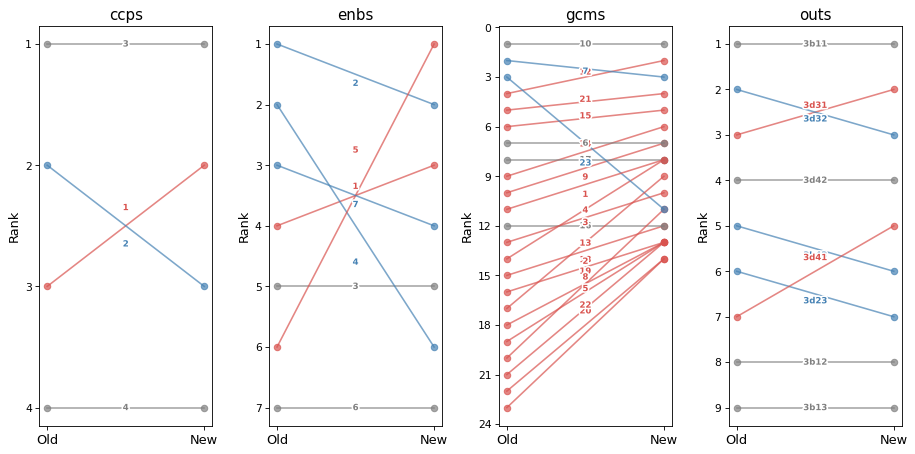

In [ ]:
df = dfs[dfs.evl_id == rpts[1]]
plot_rank_changes(df, figsize=(12, 6), dpi=77)

In [ ]:
# Was fundamental
q = 'score_old > 0.83 & mapping_type != "outs"'
print(df.query(q)[coi].to_string())

    mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
626         ccps        3       0.88       0.78         1         1          0
629         enbs        2       0.88       0.55         1         2         -1
636         gcms       10       0.95       0.97         1         1          0
655         gcms        7       0.88       0.62         2         3         -1


In [ ]:
# Is now fundamental
q = 'score_new > 0.83 & mapping_type != "outs"'
print(df.query(q)[coi].to_string())

    mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
636         gcms       10       0.95       0.97         1         1          0


Instead of the two previous queries "ranked-based", I'd like to use the "#Was fundamental" and "Is now fundamental" ones? 
But instead of displaying the dataframe then showing themes I'd like show each row of these table in the "theme_md" formatter:
    - also the reasoning should become expandable as accordions
    - the subtlety is that if a row of "Is now fundamental" was already displayed in "Was fundamental" it's uncessary to repeat it

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

First let's update `theme_md` to use `<details>` accordions for the reasoning:

```python
def theme_md(mapping_type, theme_id, old_r, new_r):
    "Render a single theme comparison as markdown with collapsible reasoning"
    o,n = get_theme(old_r, mapping_type, theme_id), get_theme(new_r, mapping_type, theme_id)
    return f"""#### {mapping_type.upper()} — {n['theme_id']}: {n['theme_title']}

| | Old | New |
|---|---|---|
| Score | {o['relevance_score']} | {n['relevance_score']} |

<details><summary>Reasoning (old)</summary>{o['reasoning']}</details>
<details><summary>Reasoning (new)</summary>{n['reasoning']}</details>"""
```

Then update `gen_report_cells`:

```python
async def gen_report_cells(rpt_id, dfs, old_results_path, new_results_path, coi):
    old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)
    title = new_r['meta']['Title'][:80]
    mid = await add_msg(f"### {title}", placement='at_end')
    mid = await add_msg(f"plot_rank_changes(dfs[dfs.evl_id == '{rpt_id}'], figsize=(12,6), dpi=77)", msg_type='code', run=False, placement='add_after', id=mid)
    df = dfs[dfs.evl_id == rpt_id]
    q1 = df.query('score_old > 0.83 & mapping_type != "outs"')
    q2 = df.query('score_new > 0.83 & mapping_type != "outs"')
    seen = set()
    for q,label in [(q1,'Was Fundamental'),(q2,'Is Now Fundamental')]:
        if not len(q): continue
        mid = await add_msg(f"**{label}**", placement='add_after', id=mid)
        for _, row in q.iterrows():
            key = (row.mapping_type, str(row.theme_id))
            if key in seen: continue
            seen.add(key)
            mid = await add_msg(theme_md(row.mapping_type, row.theme_id, old_r, new_r), placement='add_after', id=mid)
    return mid
```

<details class='token-usage-details'><summary>$0.0931</summary>

`total=24,209 | in=23,512 | out=697 | cached=43.6% | cache_new=11,648 | $0.0931`

</details>


In [ ]:
def theme_md(mapping_type, theme_id, old_r, new_r):
    "Render a single theme comparison as markdown with collapsible reasoning"
    o,n = get_theme(old_r, mapping_type, theme_id), get_theme(new_r, mapping_type, theme_id)
    return f"""#### {mapping_type.upper()} — {n['theme_id']}: {n['theme_title']}

| | Old | New |
|---|---|---|
| Score | {o['relevance_score']} | {n['relevance_score']} |

<details><summary>Reasoning (old)</summary>{o['reasoning']}</details>

--- 

<details><summary>Reasoning (new)</summary>{n['reasoning']}</details>"""

In [ ]:
async def gen_report_cells(rpt_id, dfs, old_results_path, new_results_path, coi):
    old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)
    title = new_r['meta']['Title'][:80]
    mid = await add_msg(f"### {title}", placement='at_end')
    mid = await add_msg(f"plot_rank_changes(dfs[dfs.evl_id == '{rpt_id}'], figsize=(12,6), dpi=77)", msg_type='code', run=False, placement='add_after', id=mid)
    df = dfs[dfs.evl_id == rpt_id]
    q1 = df.query('score_old > 0.83 & mapping_type != "outs"')
    q2 = df.query('score_new > 0.83 & mapping_type != "outs"')
    seen = set()
    for q,label in [(q1,'Was Fundamental'),(q2,'Is Now Fundamental')]:
        if not len(q): continue
        mid = await add_msg(f"**{label}**", placement='add_after', id=mid)
        for _, row in q.iterrows():
            key = (row.mapping_type, str(row.theme_id))
            if key in seen: continue
            seen.add(key)
            mid = await add_msg(theme_md(row.mapping_type, row.theme_id, old_r, new_r), placement='add_after', id=mid)
    return mid

In [ ]:
await gen_report_cells(rpts[1], dfs, LATEST_TAG_PATH, RESULTS_PATH, coi)

'_7d654137'

We are almost there: 
- instead of the old an new score in the "theme_md", we'd like to display the full info:
```
mapping_type theme_id  score_old  score_new  rank_old  rank_new  rank_diff
636         gcms       10       0.95       0.97         1         1          0
```
- also if the query for "Is Now Fundamental" returns and empty result or return a row already returned in the previous query, we don't print anything

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
def theme_md(mapping_type, theme_id, old_r, new_r, row):
    "Render a single theme comparison as markdown with collapsible reasoning"
    o,n = get_theme(old_r, mapping_type, theme_id), get_theme(new_r, mapping_type, theme_id)
    return f"""#### {mapping_type.upper()} — {n['theme_id']}: {n['theme_title']}

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| {row.score_old} | {row.score_new} | {row.rank_old} | {row.rank_new} | {row.rank_diff} |

<details><summary>Reasoning (old)</summary>{o['reasoning']}</details>

---

<details><summary>Reasoning (new)</summary>{n['reasoning']}</details>"""
```

```python
async def gen_report_cells(rpt_id, dfs, old_results_path, new_results_path, coi):
    old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)
    title = new_r['meta']['Title'][:80]
    mid = await add_msg(f"### {title}", placement='at_end')
    mid = await add_msg(f"plot_rank_changes(dfs[dfs.evl_id == '{rpt_id}'], figsize=(12,6), dpi=77)", msg_type='code', run=False, placement='add_after', id=mid)
    df = dfs[dfs.evl_id == rpt_id]
    q1 = df.query('score_old > 0.83 & mapping_type != "outs"')
    q2 = df.query('score_new > 0.83 & mapping_type != "outs"')
    seen = set()
    for q,label in [(q1,'Was Fundamental'),(q2,'Is Now Fundamental')]:
        new_rows = [(key:=(row.mapping_type, str(row.theme_id)), row) for _, row in q.iterrows() if (row.mapping_type, str(row.theme_id)) not in seen]
        if not new_rows: continue
        mid = await add_msg(f"**{label}**", placement='add_after', id=mid)
        for key,row in new_rows:
            seen.add(key)
            mid = await add_msg(theme_md(row.mapping_type, row.theme_id, old_r, new_r, row), placement='add_after', id=mid)
    return mid
```

<details class='token-usage-details'><summary>$0.1045</summary>

`total=25,885 | in=25,105 | out=780 | cached=40.8% | cache_new=13,784 | $0.1045`

</details>


In [ ]:
def theme_md(mapping_type, theme_id, old_r, new_r, row):
    "Render a single theme comparison as markdown with collapsible reasoning"
    o,n = get_theme(old_r, mapping_type, theme_id), get_theme(new_r, mapping_type, theme_id)
    return f"""#### {mapping_type.upper()} — {n['theme_id']}: {n['theme_title']}

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| {row.score_old} | {row.score_new} | {row.rank_old} | {row.rank_new} | {row.rank_diff} |

<details><summary>Reasoning (old)</summary>{o['reasoning']}</details>

---

<details><summary>Reasoning (new)</summary>{n['reasoning']}</details>"""

In [ ]:
row = df.iloc[0]
old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)


In [ ]:
df.iloc[0]

mapping_type                                           ccps
theme_id                                                  1
theme_title_x    Integrity, Transparency and Accountability
score_old                                              0.45
theme_title_y    Integrity, Transparency and Accountability
score_new                                              0.42
score_diff                                            -0.03
is_new                                                False
is_dropped                                            False
rank_old                                                  3
rank_new                                                  2
rank_diff                                                 1
pct_change                                        -6.666667
evl_id                     1d7e6d2d445145d1d350b48b72b36681
Name: 624, dtype: object

In [ ]:
async def gen_report_cells(rpt_id, dfs, old_results_path, new_results_path, coi):
    old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)
    title = new_r['meta']['Title']
    mid = await add_msg(f"### {title}", placement='at_end')
    mid = await add_msg(f"plot_rank_changes(dfs[dfs.evl_id == '{rpt_id}'], figsize=(12,6), dpi=77)", msg_type='code', run=False, placement='add_after', id=mid)
    df = dfs[dfs.evl_id == rpt_id]
    q1 = df.query('score_old > 0.83 & mapping_type != "outs"')
    q2 = df.query('score_new > 0.83 & mapping_type != "outs"')
    seen = set()
    for q,label in [(q1,'Was Fundamental'),(q2,'Is Now Fundamental')]:
        new_rows = [(key:=(row.mapping_type, str(row.theme_id)), row) for _, row in q.iterrows() if (row.mapping_type, str(row.theme_id)) not in seen]
        if not new_rows: continue
        mid = await add_msg(f"**{label}**", placement='add_after', id=mid)
        for key,row in new_rows:
            seen.add(key)
            mid = await add_msg(theme_md(row.mapping_type, row.theme_id, old_r, new_r, row), placement='add_after', id=mid)
    return mid

In [ ]:
await gen_report_cells(rpts[1], dfs, LATEST_TAG_PATH, RESULTS_PATH, coi)

'_2f6effb5'

### FINAL INTERNAL INDEPENDENT EVALUATION OF THE CAPACITY ENHANCEMENT FOR INSTITUTIONALIZED VICTIM CENTERED INVESTIGATIONS AND PROSECUTIONS OF TRAFFICKING IN PERSONS (TIP) CASES IN SOUTH AFRICA PROJECT

In [ ]:
plot_rank_changes(dfs[dfs.evl_id == '1d7e6d2d445145d1d350b48b72b36681'], figsize=(12,6), dpi=77)

**Was Fundamental**

#### CCPS — 3: Protection-centred

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.78 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Protection-centred approaches. The evaluation explicitly examines a project designed to promote 'victim centered investigations and prosecution' of trafficking cases, with victim protection and rights-based approaches appearing prominently in the project title, objectives, and throughout the evaluation. Multiple findings directly assess IOM's implementation of protection-centered commitments: the report evaluates direct assistance provided to 29 victims of trafficking (VOTs), analyzes the development of Standard Operating Procedures for victim care and referral, and examines capacity building aimed at ensuring 'relevant officers understand TIP and victim centered assistance.' The executive summary emphasizes that 'victim support, especially assistance in voluntary international repatriation were the most appreciated aspects of IOM's work.' Key findings address whether 'victims of TIP were now better protected or managed as a result of the project' and assess the extent to which the intervention upheld 'the rights of VOT' and placed 'the human rights and well-being of all migrants at the centre.' The evaluation also examines stakeholder coordination mechanisms designed to improve protection outcomes. For a synthesis specialist, the analysis of victim-centered approaches in the effectiveness section (4.3), the discussion of direct assistance to VOTs, the assessment of SOPs for victim protection and referral, and the findings on rights-based capacity building would be particularly valuable. This report provides direct evidence on IOM's implementation of protection-centered programming in the counter-trafficking context, including both strengths (victim assistance delivery) and gaps (limited scale of reach).</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Cross-cutting Priority 3 (Protection-centred). The project evaluated — 'Capacity Enhancement for Institutionalized Victim Centered Investigations and Prosecution of Trafficking in Persons Cases in South Africa' — is explicitly framed around victim-centered approaches to TIP management, placing the protection and wellbeing of trafficking victims at the center of its design and implementation. The excerpts suggest that protection-centred approaches are woven throughout the evaluation's objectives, findings, and conclusions. Key elements relevant to this Priority include: the development of Standard Operating Procedures for victim care and referral; direct assistance provided to 29 Victims of Trafficking (VOTs) covering protection and welfare needs; capacity building of government officials on victim identification and victim-centered assistance; and the evaluation's assessment of whether the project contributed to an 'institutionalized victim centered approach to TIP management.' The conclusions explicitly discuss the project's contribution to victim-centered TIP management as the overarching goal, and recommendations address scaling up victim assistance and protection mechanisms. The rights-based framing — referencing the Palermo Protocol, the TIP Act, and IOM's mandate to uphold human dignity — also aligns with this Priority's emphasis on rights-based approaches. However, protection-centred approaches here are assessed primarily through the lens of TIP programming effectiveness rather than as a standalone institutional commitment of IOM, which somewhat limits its direct applicability to a synthesis on IOM's organizational protection-centred commitments. Synthesis specialists would likely want to review the effectiveness and impact sections (Chapter 4, sections 4.3 and 4.5), the conclusions on victim-centered TIP management (section 5.1), and the recommendations on scaling victim assistance (section 5.2) as starting points for deeper review.</details>

#### ENBS — 2: Partnership

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.55 | 1 | 2 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Partnership. The evaluation explicitly examines IOM's partnership approach with government departments and civil society organizations in counter-trafficking work, with stakeholder coordination appearing as a primary project objective and evaluation focus. Multiple findings directly assess partnership quality, noting 'very participatory nature of project implementation enhanced ownership' and 'effective stakeholder mobilization was a pivotal aspect to timely project delivery.' The coherence and effectiveness sections provide substantive analysis of IOM's coordination with national (NICTIP) and provincial (PTTs) structures, examining both strengths and weaknesses in multi-stakeholder engagement. Key recommendations specifically address sustaining partnerships ('Remain connected with PTTs but most especially NICTIP') and elevating engagement to higher political levels. For a synthesis specialist, the analysis of partnership models with government entities in Chapter 4 (sections 4.2 Coherence and 4.3 Effectiveness), the discussion of stakeholder ownership and coordination challenges, and recommendations 3-4 on political engagement and maintaining partnerships would be particularly valuable for understanding IOM's partnership development capacities in government-facing programming.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed suggest that stakeholder engagement and coordination feature prominently in this evaluation, but on closer examination these appear to be programmatic delivery mechanisms rather than an evaluation of IOM's institutional partnership capacity. The project's core design involved engaging government departments (SAPS, DHA, DSD, NPA, DEL, DoJ, DoH), provincial task teams, and civil society organizations as implementation partners. The evaluation assesses how effectively IOM mobilized and engaged these stakeholders to deliver project outputs — SOPs, training manuals, capacity building. Recommendations 3 and 4 address maintaining engagement with NICTIP and PTTs, and Recommendation 5 calls for greater regional technical support. These touch on IOM's relational positioning with government counterparts. However, the evaluation's object appears to be the TIP programme's effectiveness, not IOM's institutional partnership frameworks, equity of partnerships, or organization-wide partnership systems. The partnership content here is primarily about programme delivery coordination rather than IOM's partnership capacity as an organizational enabler. A synthesis specialist on the Partnership Enabler might find some peripheral value in the sections on stakeholder engagement approaches and the recommendations on maintaining government relationships, but should approach this with caution given the programmatic framing.</details>

#### GCMS — 10: Prevent, combat and eradicate trafficking in persons in the context of international migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.95 | 0.97 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would be essential core evidence for a synthesis on GCM Objective 10 and virtually all its associated actions. The entire project is explicitly dedicated to combating trafficking in persons, with the stated objective to 'contribute to the Government of the Republic of South Africa and civil society efforts to uphold the rights of VOT, and, increase prosecution of TIP cases.' The evaluation comprehensively analyzes all four pillars of TIP response: Prevention, Protection, Prosecution, and Partnership (the 4Ps framework). Specific action coverage includes: Action 10b (implementation of Global Plan of Action—the project developed training manuals and SOPs aligned with international frameworks); Action 10c (monitoring routes and strengthening cooperation—extensive analysis of multi-stakeholder coordination through NICTIP and PTTs); Action 10d (information sharing and cooperation—detailed findings on stakeholder coordination mechanisms); Action 10e (addressing vulnerabilities and protection—29 VOTs assisted, victim-centered approach throughout); Action 10g (prosecution and victim protection—training for NPA, SAPS on investigations and prosecution); Action 10h (victim assistance and reintegration—direct assistance provided including repatriation); Action 10i (training and awareness for officials—core project activity with departmental training manuals developed); Action 10j (awareness campaigns—noted as a gap needing attention). For synthesis specialists, essential sections include: Chapter 4 findings on effectiveness (pages 27-36) analyzing delivery of training, SOPs, and victim assistance; the detailed stakeholder engagement analysis showing coordination mechanisms; findings on capacity building outcomes; the impact section (pages 40-44) discussing contribution to the 4Ps; sustainability analysis of TIP structures; and recommendations on scaling up anti-TIP interventions. The evaluation provides rich evidence on implementation challenges, multi-stakeholder coordination models, capacity building approaches, and victim-centered response systems. The context section also provides valuable information on South Africa's TIP legal framework (PACOTIP Act) and the US Tier ranking system as an accountability mechanism. This is a comprehensive anti-trafficking program evaluation with direct relevance to nearly all aspects of Objective 10.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would almost certainly be essential evidence for a synthesis on GCM Objective 10. Trafficking in persons (TIP) is the explicit and exclusive subject of the evaluated project, and the evaluation comprehensively assesses a multi-year counter-trafficking capacity building initiative in South Africa. The project title itself — 'Capacity Enhancement for Institutionalized Victim Centered Investigations and Prosecution of Trafficking in Persons Cases in South Africa' — directly mirrors the language of GCM Objective 10. The excerpts suggest substantive analysis across multiple associated actions: Action 10c (monitoring routes and strengthening cooperation on prosecution and victim identification), Action 10e (addressing vulnerabilities of victims and facilitating access to justice), Action 10g (strengthening legislation and prosecution while avoiding criminalization of victims), Action 10h (providing protection and assistance to VOTs), and Action 10i (training programmes for public officials and law enforcement). The evaluation covers development of Standard Operating Procedures for victim identification and referral, sector-specific training manuals for multiple government departments (SAPS, NPA, DSD, DHA, DoH, DEL, DoJ), direct assistance to 29 VOTs including voluntary international repatriation, and strengthening of multi-stakeholder coordination through provincial task teams and NICTIP. For a synthesis specialist, the findings chapters on effectiveness (section 4.3), impact (4.5), and sustainability (4.6) would appear particularly valuable, as would the conclusions on institutional capacity building and the recommendations on scaling up. The evaluation's assessment of what worked in building a victim-centered TIP management system — and what remains to be done — would likely provide rich evidence for a synthesis on this objective.</details>

#### GCMS — 7: Address and reduce vulnerabilities in migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.62 | 2 | 3 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 7, particularly Actions 7b (identification and assistance of vulnerable migrants) and 7c (gender-responsive policies addressing needs of migrant women and girls). The entire project explicitly focuses on victim-centered approaches to trafficking, which is fundamentally about addressing vulnerabilities in migration. The evaluation extensively analyzes vulnerability identification, protection mechanisms, and assistance to victims of trafficking—a core vulnerability category. Key relevant sections include: the executive summary's discussion of 'victim support, especially assistance in the voluntary international repatriation'; findings on effectiveness of victim assistance (29 VOTs assisted with 'lifesaving assistance'); analysis of gender-responsive approaches throughout; and the detailed discussion of protection and referral mechanisms in the SOPs. The evaluation explicitly examines 'holistic TIP management (Prevention, Protection, Prosecution, Partnership)' with Protection being directly relevant to vulnerability response. The findings on stakeholder coordination for victim care and the development of SOPs for victim management provide concrete evidence on vulnerability response systems. For a synthesis specialist, pay close attention to: the sections on direct assistance to VOTs, the analysis of protection mechanisms in the SOPs, findings on victim-centered approaches, and recommendations on scaling assistance. The gender dimension is particularly strong, with specific attention to vulnerabilities of women and girls in trafficking contexts.</details>

---

<details><summary>Reasoning (new)</summary>The excerpts reviewed suggest moderate relevance for a synthesis on GCM Objective 7, particularly around the identification, protection, and assistance of vulnerable migrants — specifically victims of trafficking. The project explicitly provided direct assistance to 29 Victims of Trafficking (VOTs), and the evaluation discusses victim-centered approaches, referral mechanisms, and protection and welfare assistance. Actions 7b (comprehensive policies for migrants in vulnerable situations) and 7k (involving local authorities in identification and referral) appear particularly related. However, vulnerability is addressed specifically through the TIP lens rather than as a broader migration vulnerability framework, and the analytical depth on vulnerability per se is limited compared to the institutional capacity-building focus. The sections on direct VOT assistance and the discussion of victim-centered TIP management in the effectiveness and impact chapters would be the most relevant for human reviewers to examine, though this report would likely be secondary to sources with broader vulnerability frameworks.</details>

### FINAL INTERNAL INDEPENDENT EVALUATION OF THE CAPACITY ENHANCEMENT FOR INSTITUTIO

In [ ]:
plot_rank_changes(dfs[dfs.evl_id == '1d7e6d2d445145d1d350b48b72b36681'], figsize=(12,6), dpi=77)

**Was Fundamental**

#### CCPS — 3: Protection-centred

| | Old | New |
|---|---|---|
| Score | 0.88 | 0.78 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Protection-centred approaches. The evaluation explicitly examines a project designed to promote 'victim centered investigations and prosecution' of trafficking cases, with victim protection and rights-based approaches appearing prominently in the project title, objectives, and throughout the evaluation. Multiple findings directly assess IOM's implementation of protection-centered commitments: the report evaluates direct assistance provided to 29 victims of trafficking (VOTs), analyzes the development of Standard Operating Procedures for victim care and referral, and examines capacity building aimed at ensuring 'relevant officers understand TIP and victim centered assistance.' The executive summary emphasizes that 'victim support, especially assistance in voluntary international repatriation were the most appreciated aspects of IOM's work.' Key findings address whether 'victims of TIP were now better protected or managed as a result of the project' and assess the extent to which the intervention upheld 'the rights of VOT' and placed 'the human rights and well-being of all migrants at the centre.' The evaluation also examines stakeholder coordination mechanisms designed to improve protection outcomes. For a synthesis specialist, the analysis of victim-centered approaches in the effectiveness section (4.3), the discussion of direct assistance to VOTs, the assessment of SOPs for victim protection and referral, and the findings on rights-based capacity building would be particularly valuable. This report provides direct evidence on IOM's implementation of protection-centered programming in the counter-trafficking context, including both strengths (victim assistance delivery) and gaps (limited scale of reach).</details>

--- 

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Cross-cutting Priority 3 (Protection-centred). The project evaluated — 'Capacity Enhancement for Institutionalized Victim Centered Investigations and Prosecution of Trafficking in Persons Cases in South Africa' — is explicitly framed around victim-centered approaches to TIP management, placing the protection and wellbeing of trafficking victims at the center of its design and implementation. The excerpts suggest that protection-centred approaches are woven throughout the evaluation's objectives, findings, and conclusions. Key elements relevant to this Priority include: the development of Standard Operating Procedures for victim care and referral; direct assistance provided to 29 Victims of Trafficking (VOTs) covering protection and welfare needs; capacity building of government officials on victim identification and victim-centered assistance; and the evaluation's assessment of whether the project contributed to an 'institutionalized victim centered approach to TIP management.' The conclusions explicitly discuss the project's contribution to victim-centered TIP management as the overarching goal, and recommendations address scaling up victim assistance and protection mechanisms. The rights-based framing — referencing the Palermo Protocol, the TIP Act, and IOM's mandate to uphold human dignity — also aligns with this Priority's emphasis on rights-based approaches. However, protection-centred approaches here are assessed primarily through the lens of TIP programming effectiveness rather than as a standalone institutional commitment of IOM, which somewhat limits its direct applicability to a synthesis on IOM's organizational protection-centred commitments. Synthesis specialists would likely want to review the effectiveness and impact sections (Chapter 4, sections 4.3 and 4.5), the conclusions on victim-centered TIP management (section 5.1), and the recommendations on scaling victim assistance (section 5.2) as starting points for deeper review.</details>

#### ENBS — 2: Partnership

| | Old | New |
|---|---|---|
| Score | 0.88 | 0.55 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Partnership. The evaluation explicitly examines IOM's partnership approach with government departments and civil society organizations in counter-trafficking work, with stakeholder coordination appearing as a primary project objective and evaluation focus. Multiple findings directly assess partnership quality, noting 'very participatory nature of project implementation enhanced ownership' and 'effective stakeholder mobilization was a pivotal aspect to timely project delivery.' The coherence and effectiveness sections provide substantive analysis of IOM's coordination with national (NICTIP) and provincial (PTTs) structures, examining both strengths and weaknesses in multi-stakeholder engagement. Key recommendations specifically address sustaining partnerships ('Remain connected with PTTs but most especially NICTIP') and elevating engagement to higher political levels. For a synthesis specialist, the analysis of partnership models with government entities in Chapter 4 (sections 4.2 Coherence and 4.3 Effectiveness), the discussion of stakeholder ownership and coordination challenges, and recommendations 3-4 on political engagement and maintaining partnerships would be particularly valuable for understanding IOM's partnership development capacities in government-facing programming.</details>

--- 

<details><summary>Reasoning (new)</summary>The excerpts reviewed suggest that stakeholder engagement and coordination feature prominently in this evaluation, but on closer examination these appear to be programmatic delivery mechanisms rather than an evaluation of IOM's institutional partnership capacity. The project's core design involved engaging government departments (SAPS, DHA, DSD, NPA, DEL, DoJ, DoH), provincial task teams, and civil society organizations as implementation partners. The evaluation assesses how effectively IOM mobilized and engaged these stakeholders to deliver project outputs — SOPs, training manuals, capacity building. Recommendations 3 and 4 address maintaining engagement with NICTIP and PTTs, and Recommendation 5 calls for greater regional technical support. These touch on IOM's relational positioning with government counterparts. However, the evaluation's object appears to be the TIP programme's effectiveness, not IOM's institutional partnership frameworks, equity of partnerships, or organization-wide partnership systems. The partnership content here is primarily about programme delivery coordination rather than IOM's partnership capacity as an organizational enabler. A synthesis specialist on the Partnership Enabler might find some peripheral value in the sections on stakeholder engagement approaches and the recommendations on maintaining government relationships, but should approach this with caution given the programmatic framing.</details>

#### GCMS — 10: Prevent, combat and eradicate trafficking in persons in the context of international migration

| | Old | New |
|---|---|---|
| Score | 0.95 | 0.97 |

<details><summary>Reasoning (old)</summary>This report would be essential core evidence for a synthesis on GCM Objective 10 and virtually all its associated actions. The entire project is explicitly dedicated to combating trafficking in persons, with the stated objective to 'contribute to the Government of the Republic of South Africa and civil society efforts to uphold the rights of VOT, and, increase prosecution of TIP cases.' The evaluation comprehensively analyzes all four pillars of TIP response: Prevention, Protection, Prosecution, and Partnership (the 4Ps framework). Specific action coverage includes: Action 10b (implementation of Global Plan of Action—the project developed training manuals and SOPs aligned with international frameworks); Action 10c (monitoring routes and strengthening cooperation—extensive analysis of multi-stakeholder coordination through NICTIP and PTTs); Action 10d (information sharing and cooperation—detailed findings on stakeholder coordination mechanisms); Action 10e (addressing vulnerabilities and protection—29 VOTs assisted, victim-centered approach throughout); Action 10g (prosecution and victim protection—training for NPA, SAPS on investigations and prosecution); Action 10h (victim assistance and reintegration—direct assistance provided including repatriation); Action 10i (training and awareness for officials—core project activity with departmental training manuals developed); Action 10j (awareness campaigns—noted as a gap needing attention). For synthesis specialists, essential sections include: Chapter 4 findings on effectiveness (pages 27-36) analyzing delivery of training, SOPs, and victim assistance; the detailed stakeholder engagement analysis showing coordination mechanisms; findings on capacity building outcomes; the impact section (pages 40-44) discussing contribution to the 4Ps; sustainability analysis of TIP structures; and recommendations on scaling up anti-TIP interventions. The evaluation provides rich evidence on implementation challenges, multi-stakeholder coordination models, capacity building approaches, and victim-centered response systems. The context section also provides valuable information on South Africa's TIP legal framework (PACOTIP Act) and the US Tier ranking system as an accountability mechanism. This is a comprehensive anti-trafficking program evaluation with direct relevance to nearly all aspects of Objective 10.</details>

--- 

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would almost certainly be essential evidence for a synthesis on GCM Objective 10. Trafficking in persons (TIP) is the explicit and exclusive subject of the evaluated project, and the evaluation comprehensively assesses a multi-year counter-trafficking capacity building initiative in South Africa. The project title itself — 'Capacity Enhancement for Institutionalized Victim Centered Investigations and Prosecution of Trafficking in Persons Cases in South Africa' — directly mirrors the language of GCM Objective 10. The excerpts suggest substantive analysis across multiple associated actions: Action 10c (monitoring routes and strengthening cooperation on prosecution and victim identification), Action 10e (addressing vulnerabilities of victims and facilitating access to justice), Action 10g (strengthening legislation and prosecution while avoiding criminalization of victims), Action 10h (providing protection and assistance to VOTs), and Action 10i (training programmes for public officials and law enforcement). The evaluation covers development of Standard Operating Procedures for victim identification and referral, sector-specific training manuals for multiple government departments (SAPS, NPA, DSD, DHA, DoH, DEL, DoJ), direct assistance to 29 VOTs including voluntary international repatriation, and strengthening of multi-stakeholder coordination through provincial task teams and NICTIP. For a synthesis specialist, the findings chapters on effectiveness (section 4.3), impact (4.5), and sustainability (4.6) would appear particularly valuable, as would the conclusions on institutional capacity building and the recommendations on scaling up. The evaluation's assessment of what worked in building a victim-centered TIP management system — and what remains to be done — would likely provide rich evidence for a synthesis on this objective.</details>

#### GCMS — 7: Address and reduce vulnerabilities in migration

| | Old | New |
|---|---|---|
| Score | 0.88 | 0.62 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 7, particularly Actions 7b (identification and assistance of vulnerable migrants) and 7c (gender-responsive policies addressing needs of migrant women and girls). The entire project explicitly focuses on victim-centered approaches to trafficking, which is fundamentally about addressing vulnerabilities in migration. The evaluation extensively analyzes vulnerability identification, protection mechanisms, and assistance to victims of trafficking—a core vulnerability category. Key relevant sections include: the executive summary's discussion of 'victim support, especially assistance in the voluntary international repatriation'; findings on effectiveness of victim assistance (29 VOTs assisted with 'lifesaving assistance'); analysis of gender-responsive approaches throughout; and the detailed discussion of protection and referral mechanisms in the SOPs. The evaluation explicitly examines 'holistic TIP management (Prevention, Protection, Prosecution, Partnership)' with Protection being directly relevant to vulnerability response. The findings on stakeholder coordination for victim care and the development of SOPs for victim management provide concrete evidence on vulnerability response systems. For a synthesis specialist, pay close attention to: the sections on direct assistance to VOTs, the analysis of protection mechanisms in the SOPs, findings on victim-centered approaches, and recommendations on scaling assistance. The gender dimension is particularly strong, with specific attention to vulnerabilities of women and girls in trafficking contexts.</details>

--- 

<details><summary>Reasoning (new)</summary>The excerpts reviewed suggest moderate relevance for a synthesis on GCM Objective 7, particularly around the identification, protection, and assistance of vulnerable migrants — specifically victims of trafficking. The project explicitly provided direct assistance to 29 Victims of Trafficking (VOTs), and the evaluation discusses victim-centered approaches, referral mechanisms, and protection and welfare assistance. Actions 7b (comprehensive policies for migrants in vulnerable situations) and 7k (involving local authorities in identification and referral) appear particularly related. However, vulnerability is addressed specifically through the TIP lens rather than as a broader migration vulnerability framework, and the analytical depth on vulnerability per se is limited compared to the institutional capacity-building focus. The sections on direct VOT assistance and the discussion of victim-centered TIP management in the effectiveness and impact chapters would be the most relevant for human reviewers to examine, though this report would likely be secondary to sources with broader vulnerability frameworks.</details>

**Is Now Fundamental**